In [2]:
import pandas as pd
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria

# 1. Fazendo a consulta no banco de dados de forma assíncrona
async with AsyncSessionLocal() as session:
    resultado = await session.execute(select(ResultadoLoteria))
    loterias = resultado.scalars().all()

# 2. Convertendo os resultados para uma tabela do Pandas (DataFrame)
dados = [item.__dict__ for item in loterias]
df = pd.DataFrame(dados)

# Limpando a coluna interna que o SQLAlchemy usa para controle
if '_sa_instance_state' in df.columns:
    df = df.drop(columns=['_sa_instance_state'])

# 3. Exibindo as 5 primeiras linhas para conferência!
df.head()

,data_hora,id,horario,resultado,tipo_resultado,no_loteria,id_loteria,criado_em,dt_sorteio,dt_horario_sorteio,premio,id_concurso,no_apelido,tempo_restante_segundos
0,2026-07-15 15:00:00,36493bda-8f54-4c56-9062-8e5142498163,15:00,7868,TD,Nacional,35,2026-07-15 18:52:13.999502,15/07/2026,2026-07-15 15:00:00,1,0,Nacional 15:00,0
1,2026-07-15 15:00:00,43af41cd-99b6-437f-8d65-f9931b9fa449,15:00,0540,TD,Nacional,35,2026-07-15 18:52:13.999509,15/07/2026,2026-07-15 15:00:00,2,0,Nacional 15:00,0
2,2026-07-15 15:00:00,24045d81-377e-4039-9c1d-808a7e5ffad6,15:00,2588,TD,Nacional,35,2026-07-15 18:52:13.999513,15/07/2026,2026-07-15 15:00:00,3,0,Nacional 15:00,0
3,2026-07-15 15:00:00,ecbe7e14-7f61-478e-92d0-d366acfa66d5,15:00,6963,TD,Nacional,35,2026-07-15 18:52:13.999515,15/07/2026,2026-07-15 15:00:00,4,0,Nacional 15:00,0
4,2026-07-15 15:00:00,bcf549e1-3071-4649-980a-29a49861c805,15:00,2777,TD,Nacional,35,2026-07-15 18:52:13.999517,15/07/2026,2026-07-15 15:00:00,5,0,Nacional 15:00,0


C:\Users\vinicius.pais\AppData\Local\Temp\ipykernel_17952\2995302.py:24: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vinicius.pais\lottery-predictive-scraper\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


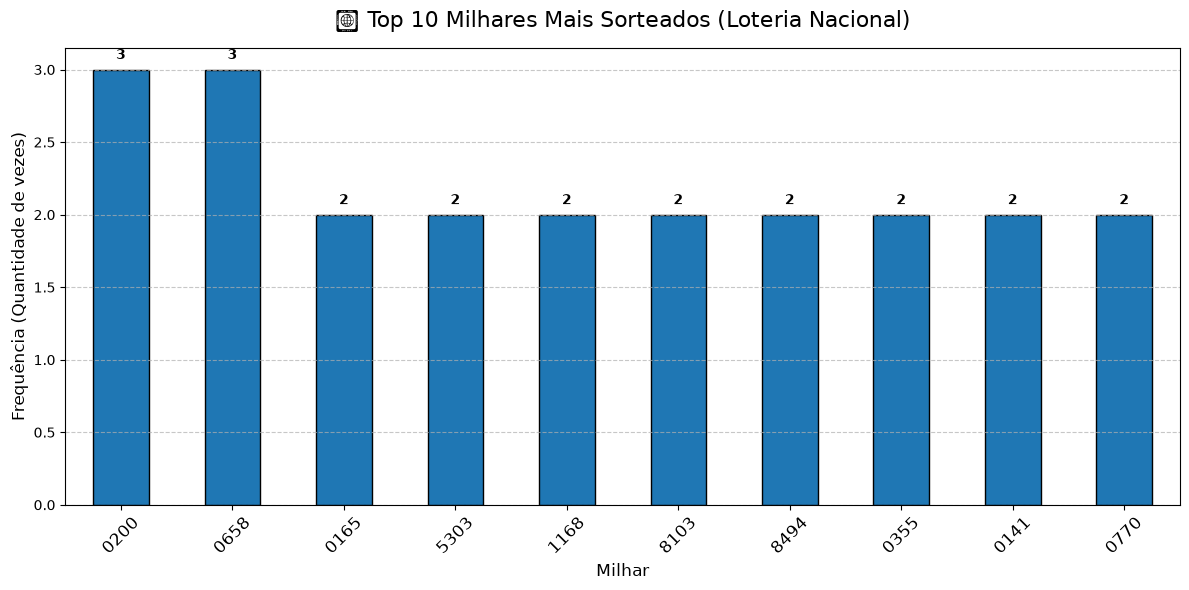

In [3]:
import matplotlib.pyplot as plt

# 1. Filtrando para pegar apenas os resultados da loteria "Nacional"
df_nacional = df[df['no_loteria'] == 'Nacional']

# 2. Contando a frequência de cada milhar (resultado completo) e pegando o Top 10
top_10_milhares = df_nacional['resultado'].value_counts().head(10)

# 3. Criando o Gráfico de Barras
plt.figure(figsize=(12, 6))
grafico_milhar = top_10_milhares.plot(kind='bar', color='#1f77b4', edgecolor='black')

# 4. Deixando o gráfico com cara de relatório profissional
plt.title('🎯 Top 10 Milhares Mais Sorteados (Loteria Nacional)', fontsize=16, pad=15)
plt.xlabel('Milhar', fontsize=12)
plt.ylabel('Frequência (Quantidade de vezes)', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando os números exatos em cima de cada barra
for i, v in enumerate(top_10_milhares):
    grafico_milhar.text(i, v + 0.05, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import itertools

# 1. Garantindo que a coluna de data é do tipo datetime
df['data_hora'] = pd.to_datetime(df['data_hora'])

# 2. Filtrando exatamente os últimos 15 dias com base na data mais recente do banco
data_recente = df['data_hora'].max()
data_limite = data_recente - pd.Timedelta(days=15)
df_15_dias = df[df['data_hora'] >= data_limite].copy()

# 3. Engenharia de Features: Pegando apenas a Dezena (últimos 2 dígitos do resultado)
df_15_dias['dezena'] = df_15_dias['resultado'].str[-2:]

# 4. Pegando as 6 dezenas mais "Quentes" (frequentes)
dezenas_quentes = df_15_dias['dezena'].value_counts().head(6).index.tolist()

# 5. Gerando as combinações de Ternos (Grupos de 3)
# Com 6 dezenas, podemos formar exatamente 20 combinações únicas de 3. Vamos pegar 10.
combinacoes_ternos = list(itertools.combinations(dezenas_quentes, 3))
ternos_sugeridos = combinacoes_ternos[:10]

# 6. Exibindo os resultados como um relatório
print("🔥 ANÁLISE PREDITIVA: ÚLTIMOS 15 DIAS 🔥")
print(f"Período analisado: {data_limite.strftime('%d/%m/%Y')} até {data_recente.strftime('%d/%m/%Y')}\n")
print(f"As 6 Dezenas Mais Quentes: {', '.join(dezenas_quentes)}\n")

print("🎲 SUGESTÃO DE 10 TERNOS DE DEZENAS BASEADOS NA FREQUÊNCIA:")
print("-" * 50)
for i, terno in enumerate(ternos_sugeridos, 1):
    print(f"Terno {i:02d}: {terno[0]} - {terno[1]} - {terno[2]}")
print("-" * 50)
print("Boa sorte nas análises!")

🔥 ANÁLISE PREDITIVA: ÚLTIMOS 15 DIAS 🔥
Período analisado: 30/06/2026 até 15/07/2026

As 6 Dezenas Mais Quentes: 01, 03, 05, 23, 10, 18

🎲 SUGESTÃO DE 10 TERNOS DE DEZENAS BASEADOS NA FREQUÊNCIA:
--------------------------------------------------
Terno 01: 01 - 03 - 05
Terno 02: 01 - 03 - 23
Terno 03: 01 - 03 - 10
Terno 04: 01 - 03 - 18
Terno 05: 01 - 05 - 23
Terno 06: 01 - 05 - 10
Terno 07: 01 - 05 - 18
Terno 08: 01 - 23 - 10
Terno 09: 01 - 23 - 18
Terno 10: 01 - 10 - 18
--------------------------------------------------
Boa sorte nas análises!


In [5]:
import pandas as pd
import itertools

# Função clássica da loteria: converte a Dezena (00-99) no Grupo correto (1-25)
def converter_para_grupo(dezena_str):
    dezena_int = int(dezena_str)
    if dezena_int == 0:  # A dezena '00' pertence ao grupo 25
        return 25
    # Fórmula matemática para achar o grupo (ex: dezena 13 -> 12 // 4 = 3 + 1 = Grupo 4)
    return ((dezena_int - 1) // 4) + 1

# 1. Garantindo a data e pegando os últimos 15 dias
df['data_hora'] = pd.to_datetime(df['data_hora'])
data_recente = df['data_hora'].max()
data_limite = data_recente - pd.Timedelta(days=15)
df_15_dias = df[df['data_hora'] >= data_limite].copy()

# 2. Extraindo a Dezena e calculando o Grupo
df_15_dias['dezena'] = df_15_dias['resultado'].str[-2:]
df_15_dias['grupo'] = df_15_dias['dezena'].apply(converter_para_grupo)

# 3. Descobrindo os 6 Grupos mais "Quentes" (que mais saíram nesses 15 dias)
grupos_quentes = df_15_dias['grupo'].value_counts().head(6).index.tolist()

# 4. Cruzando esses 6 grupos para gerar as combinações exatas de Ternos de Grupo
combinacoes_grupos = list(itertools.combinations(grupos_quentes, 3))
ternos_grupo_sugeridos = combinacoes_grupos[:10]

# 5. Imprimindo o relatório estruturado
print("🐾 ANÁLISE PREDITIVA: TERNO DE GRUPO (ÚLTIMOS 15 DIAS) 🐾\n")
print(f"Os 6 Grupos Mais Quentes: {', '.join([f'{g:02d}' for g in grupos_quentes])}\n")

print("🎲 SUGESTÃO DE 10 TERNOS DE GRUPO:")
print("-" * 50)
for i, terno in enumerate(ternos_grupo_sugeridos, 1):
    # Formata para ficar bonitinho com dois zeros (ex: 04 em vez de 4)
    t_formatado = f"Grupo {terno[0]:02d} - Grupo {terno[1]:02d} - Grupo {terno[2]:02d}"
    print(f"Terno {i:02d}: {t_formatado}")
print("-" * 50)
print("Boa sorte nas análises!")

🐾 ANÁLISE PREDITIVA: TERNO DE GRUPO (ÚLTIMOS 15 DIAS) 🐾

Os 6 Grupos Mais Quentes: 01, 02, 03, 05, 04, 06

🎲 SUGESTÃO DE 10 TERNOS DE GRUPO:
--------------------------------------------------
Terno 01: Grupo 01 - Grupo 02 - Grupo 03
Terno 02: Grupo 01 - Grupo 02 - Grupo 05
Terno 03: Grupo 01 - Grupo 02 - Grupo 04
Terno 04: Grupo 01 - Grupo 02 - Grupo 06
Terno 05: Grupo 01 - Grupo 03 - Grupo 05
Terno 06: Grupo 01 - Grupo 03 - Grupo 04
Terno 07: Grupo 01 - Grupo 03 - Grupo 06
Terno 08: Grupo 01 - Grupo 05 - Grupo 04
Terno 09: Grupo 01 - Grupo 05 - Grupo 06
Terno 10: Grupo 01 - Grupo 04 - Grupo 06
--------------------------------------------------
Boa sorte nas análises!


In [6]:
import pandas as pd
import itertools

# Mapeamento exato da "Tabela de Bichos, Grupos e Dezenas" da imagem fornecida
TABELA_BICHOS = {
    1: "AVESTRUZ", 2: "ÁGUIA", 3: "BURRO", 4: "BORBOLETA", 5: "CACHORRO",
    6: "CABRA", 7: "CARNEIRO", 8: "CAMELO", 9: "COBRA", 10: "COELHO",
    11: "CAVALO", 12: "ELEFANTE", 13: "GALO", 14: "GATO", 15: "JACARÉ",
    16: "LEÃO", 17: "MACACO", 18: "PORCO", 19: "PAVÃO", 20: "PERU",
    21: "TOURO", 22: "TIGRE", 23: "URSO", 24: "VEADO", 25: "VACA"
}

def converter_para_grupo(dezena_str):
    try:
        dezena_int = int(dezena_str)
        if dezena_int == 0:  # A dezena '00' pertence à Vaca (Grupo 25)
            return 25
        # Fórmula matemática para achar o grupo com base no range de 4 dezenas
        return ((dezena_int - 1) // 4) + 1
    except ValueError:
        return None

# 1. Garantindo a data e filtrando os últimos 15 dias do banco de dados
df['data_hora'] = pd.to_datetime(df['data_hora'])
data_recente = df['data_hora'].max()
data_limite = data_recente - pd.Timedelta(days=15)
df_15_dias = df[df['data_hora'] >= data_limite].copy()

# 2. Extraindo a Dezena (2 últimos dígitos) e calculando o Grupo (1 a 25)
df_15_dias['dezena'] = df_15_dias['resultado'].str[-2:]
df_15_dias['grupo'] = df_15_dias['dezena'].apply(converter_para_grupo)

# 3. Descobrindo os 6 Grupos mais "Quentes" (que mais saíram no período)
grupos_quentes = df_15_dias['grupo'].value_counts().head(6).index.tolist()

# 4. Cruzando esses 6 grupos para gerar as combinações de Ternos de Grupos (3 a 3)
combinacoes_grupos = list(itertools.combinations(grupos_quentes, 3))
ternos_grupo_sugeridos = combinacoes_grupos[:10]

# 5. Imprimindo o relatório preditivo estruturado
print("🐾 ANÁLISE PREDITIVA: 10 TERNOS DE GRUPO 🐾\n")
print(f"Período analisado: {data_limite.strftime('%d/%m/%Y')} até {data_recente.strftime('%d/%m/%Y')}\n")

print("🔥 TOP 6 GRUPOS MAIS QUENTES (Frequência Alta):")
for g in grupos_quentes:
    print(f"Grupo {g:02d} - {TABELA_BICHOS[g]}")
print("\n" + "="*70 + "\n")

print("🎲 10 SUGESTÕES PREDITIVAS DE TERNOS DE GRUPO:")
for i, terno in enumerate(ternos_grupo_sugeridos, 1):
    bicho1 = TABELA_BICHOS[terno[0]]
    bicho2 = TABELA_BICHOS[terno[1]]
    bicho3 = TABELA_BICHOS[terno[2]]
    
    texto_terno = f"Grupo {terno[0]:02d} ({bicho1}) | Grupo {terno[1]:02d} ({bicho2}) | Grupo {terno[2]:02d} ({bicho3})"
    print(f"Terno {i:02d}: {texto_terno}")
print("\n" + "="*70)

🐾 ANÁLISE PREDITIVA: 10 TERNOS DE GRUPO 🐾

Período analisado: 30/06/2026 até 15/07/2026

🔥 TOP 6 GRUPOS MAIS QUENTES (Frequência Alta):
Grupo 01 - AVESTRUZ
Grupo 02 - ÁGUIA
Grupo 03 - BURRO
Grupo 05 - CACHORRO
Grupo 04 - BORBOLETA
Grupo 06 - CABRA


🎲 10 SUGESTÕES PREDITIVAS DE TERNOS DE GRUPO:
Terno 01: Grupo 01 (AVESTRUZ) | Grupo 02 (ÁGUIA) | Grupo 03 (BURRO)
Terno 02: Grupo 01 (AVESTRUZ) | Grupo 02 (ÁGUIA) | Grupo 05 (CACHORRO)
Terno 03: Grupo 01 (AVESTRUZ) | Grupo 02 (ÁGUIA) | Grupo 04 (BORBOLETA)
Terno 04: Grupo 01 (AVESTRUZ) | Grupo 02 (ÁGUIA) | Grupo 06 (CABRA)
Terno 05: Grupo 01 (AVESTRUZ) | Grupo 03 (BURRO) | Grupo 05 (CACHORRO)
Terno 06: Grupo 01 (AVESTRUZ) | Grupo 03 (BURRO) | Grupo 04 (BORBOLETA)
Terno 07: Grupo 01 (AVESTRUZ) | Grupo 03 (BURRO) | Grupo 06 (CABRA)
Terno 08: Grupo 01 (AVESTRUZ) | Grupo 05 (CACHORRO) | Grupo 04 (BORBOLETA)
Terno 09: Grupo 01 (AVESTRUZ) | Grupo 05 (CACHORRO) | Grupo 06 (CABRA)
Terno 10: Grupo 01 (AVESTRUZ) | Grupo 04 (BORBOLETA) | Grupo 06 (CAB

In [7]:
import pandas as pd
import itertools
from collections import Counter

# Mapeamento da Tabela de Bichos
TABELA_BICHOS = {
    1: "AVESTRUZ", 2: "ÁGUIA", 3: "BURRO", 4: "BORBOLETA", 5: "CACHORRO",
    6: "CABRA", 7: "CARNEIRO", 8: "CAMELO", 9: "COBRA", 10: "COELHO",
    11: "CAVALO", 12: "ELEFANTE", 13: "GALO", 14: "GATO", 15: "JACARÉ",
    16: "LEÃO", 17: "MACACO", 18: "PORCO", 19: "PAVÃO", 20: "PERU",
    21: "TOURO", 22: "TIGRE", 23: "URSO", 24: "VEADO", 25: "VACA"
}

def converter_para_grupo(dezena_str):
    try:
        dezena_int = int(dezena_str)
        if dezena_int == 0:
            return 25
        return ((dezena_int - 1) // 4) + 1
    except ValueError:
        return None

# 1. Preparando os dados: convertendo dezenas para nomes dos bichos
df['dezena'] = df['resultado'].str[-2:]
df['grupo'] = df['dezena'].apply(converter_para_grupo)
df['bicho'] = df['grupo'].map(TABELA_BICHOS)

# 2. Agrupando os resultados por SORTEIO (Ex: todos os prêmios da Nacional das 12:00 de um dia)
# O '.unique()' garante que se o mesmo bicho sair duas vezes no mesmo sorteio, contaremos apenas 1 vez para formar o casal
sorteios = df.groupby(['data_hora', 'no_loteria'])['bicho'].unique()

# 3. Contando a frequência dos casais (combinações de 2 bichos)
frequencia_casais = Counter()

for bichos_no_sorteio in sorteios:
    # Só podemos formar casais se houver pelo menos 2 bichos diferentes no sorteio
    if len(bichos_no_sorteio) >= 2:
        # Ordenamos alfabeticamente para garantir que (Gato, Cachorro) seja igual a (Cachorro, Gato)
        bichos_ordenados = sorted(bichos_no_sorteio)
        pares = list(itertools.combinations(bichos_ordenados, 2))
        frequencia_casais.update(pares)

# 4. Pegando o Top 10 casais
top_10_casais = frequencia_casais.most_common(10)

# 5. Exibindo o relatório
print("👩‍❤️‍👨 ANÁLISE PREDITIVA: CASAIS DE BICHOS MAIS FREQUENTES (DUQUE DE GRUPO) 👨‍❤️‍👨\n")
print("Os pares de animais que mais costumam sair JUNTOS na mesma rodada:\n")

for i, (casal, frequencia) in enumerate(top_10_casais, 1):
    print(f"Top {i:02d}: {casal[0]} & {casal[1]} -> Saíram juntos em {frequencia} sorteios!")

👩‍❤️‍👨 ANÁLISE PREDITIVA: CASAIS DE BICHOS MAIS FREQUENTES (DUQUE DE GRUPO) 👨‍❤️‍👨

Os pares de animais que mais costumam sair JUNTOS na mesma rodada:

Top 01: AVESTRUZ & BURRO -> Saíram juntos em 56 sorteios!
Top 02: AVESTRUZ & ÁGUIA -> Saíram juntos em 54 sorteios!
Top 03: BURRO & ÁGUIA -> Saíram juntos em 48 sorteios!
Top 04: AVESTRUZ & BORBOLETA -> Saíram juntos em 47 sorteios!
Top 05: AVESTRUZ & CACHORRO -> Saíram juntos em 47 sorteios!
Top 06: AVESTRUZ & CABRA -> Saíram juntos em 45 sorteios!
Top 07: BURRO & CACHORRO -> Saíram juntos em 45 sorteios!
Top 08: CABRA & ÁGUIA -> Saíram juntos em 43 sorteios!
Top 09: BORBOLETA & BURRO -> Saíram juntos em 42 sorteios!
Top 10: BORBOLETA & CABRA -> Saíram juntos em 41 sorteios!


In [8]:
import pandas as pd

# 1. Filtrando apenas a loteria Nacional (que possui 4 dígitos)
df_nacional = df[df['no_loteria'] == 'Nacional']

# 2. Contando a frequência de todos os milhares sorteados
frequencia_milhares = df_nacional['resultado'].value_counts()

# 3. Pegando os "mais fracos" (que saíram menos vezes no período)
# Como muitos saíram apenas 1 vez, vamos pegar os últimos da nossa lista
milhares_fracos = frequencia_milhares.tail(10)

print("📉 ANÁLISE PREDITIVA: MILHARES MAIS FRACOS 📉\n")
print("Estes são alguns dos milhares com o pior desempenho no período analisado:\n")

for milhar, freq in milhares_fracos.items():
    print(f"Milhar {milhar} -> Saiu apenas {freq} vez(es)")

# 4. O verdadeiro pulo do gato estatístico: descobrindo os atrasados
total_possivel = 10000
milhares_sorteados = len(frequencia_milhares)
nunca_sairam = total_possivel - milhares_sorteados

print("\n" + "="*70)
print(f"💡 DICA DE CIENTISTA DE DADOS:")
print(f"Dos 10.000 milhares possíveis (de 0000 a 9999), exatamente {nunca_sairam}")
print(f"milhares NUNCA SAÍRAM neste período. Eles são os verdadeiros milhares 'frios'!")
print("="*70)

📉 ANÁLISE PREDITIVA: MILHARES MAIS FRACOS 📉

Estes são alguns dos milhares com o pior desempenho no período analisado:

Milhar 3703 -> Saiu apenas 1 vez(es)
Milhar 3153 -> Saiu apenas 1 vez(es)
Milhar 8153 -> Saiu apenas 1 vez(es)
Milhar 0872 -> Saiu apenas 1 vez(es)
Milhar 4316 -> Saiu apenas 1 vez(es)
Milhar 2933 -> Saiu apenas 1 vez(es)
Milhar 7581 -> Saiu apenas 1 vez(es)
Milhar 9333 -> Saiu apenas 1 vez(es)
Milhar 3692 -> Saiu apenas 1 vez(es)
Milhar 7855 -> Saiu apenas 1 vez(es)

💡 DICA DE CIENTISTA DE DADOS:
Dos 10.000 milhares possíveis (de 0000 a 9999), exatamente 9219
milhares NUNCA SAÍRAM neste período. Eles são os verdadeiros milhares 'frios'!
